# Ansys MAPDL: `.cdb` decks and `.rst` results

Two MAPDL formats, reworked and added in v16.3.0:

- **The coded database (`.cdb`)** is the text archive MAPDL writes with `CDWRITE`, and what Workbench and HyperMesh export for MAPDL. meshio++ cuts each block by its own Fortran format line, resolves degenerate bricks and shells by their repeated nodes, creates missing midside nodes, and reads components as named regions. The writer emits MAPDL's own layouts.
- **The results file (`.rst`, `.rth`)** is MAPDL's binary results: the model once, then one result set per load step, substep or mode. meshio++ reads the mesh and each set's nodal solution, so an analysis converts to a `.vtu` sequence.

The files are in `tests/python/meshes/ansys/`: decks from mapdl-archive and result files from pymapdl-reader (both MIT), all written by MAPDL, Workbench or HyperMesh.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460)):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector((-1.0, -1.4, 0.45), viewup=(0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Degenerate shapes

SOLID186 is a 20-node brick, and MAPDL writes wedges, pyramids and tetrahedra as bricks with repeated nodes. `all_solid_cells.cdb` holds one of each. Its `EBLOCK` rows show the repetition in their corner nodes I..P: the wedge has K = L and O = P, the pyramid M = N = O = P, the tetrahedron both. meshio++ reads four cells of four types, each with its own node order.

In [2]:
deck = path('ansys', 'all_solid_cells.cdb')
with open(deck) as fh:
    lines = fh.read().splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith('EBLOCK'))
print(lines[start], lines[start + 1])
rows = lines[start + 2:start + 10]  # four elements, two lines each, in (19i8)
for first, second in zip(rows[0::2], rows[1::2]):
    fields = [int(line[c:c + 8]) for line in (first, second) for c in range(0, len(line.rstrip()), 8)]
    print(f'element {fields[10]:5d}: corners I..P = {fields[11:19]}')
solids = mp.read(deck)
print(solids)
for block, routine in zip(solids.cells, solids.cell_data['ansys:element']):
    print(f'{block.type:13s} {block.data.shape[1]:2d} nodes   ansys:element = {routine[0]}')

EBLOCK,19,SOLID,      4644,         4 (19i8)
element  2170: corners I..P = [1071, 1148, 668, 635, 4986, 6006, 845, 638]
element  4488: corners I..P = [5692, 5649, 5697, 5697, 13153, 13148, 13154, 13154]
element  4643: corners I..P = [941, 939, 919, 921, 13984, 13984, 13984, 13984]
element  4644: corners I..P = [13983, 921, 919, 919, 13984, 13984, 13984, 13984]
<meshio++ mesh object>
  Number of points: 52
  Number of cells:
    hexahedron20: 1
    wedge15: 1
    pyramid13: 1
    tetra10: 1
  Cell data: ansys:element, ansys:mat, ansys:real, ansys:secnum, ansys:type
hexahedron20  20 nodes   ansys:element = 186
wedge15       15 nodes   ansys:element = 186
pyramid13     13 nodes   ansys:element = 186
tetra10       10 nodes   ansys:element = 186


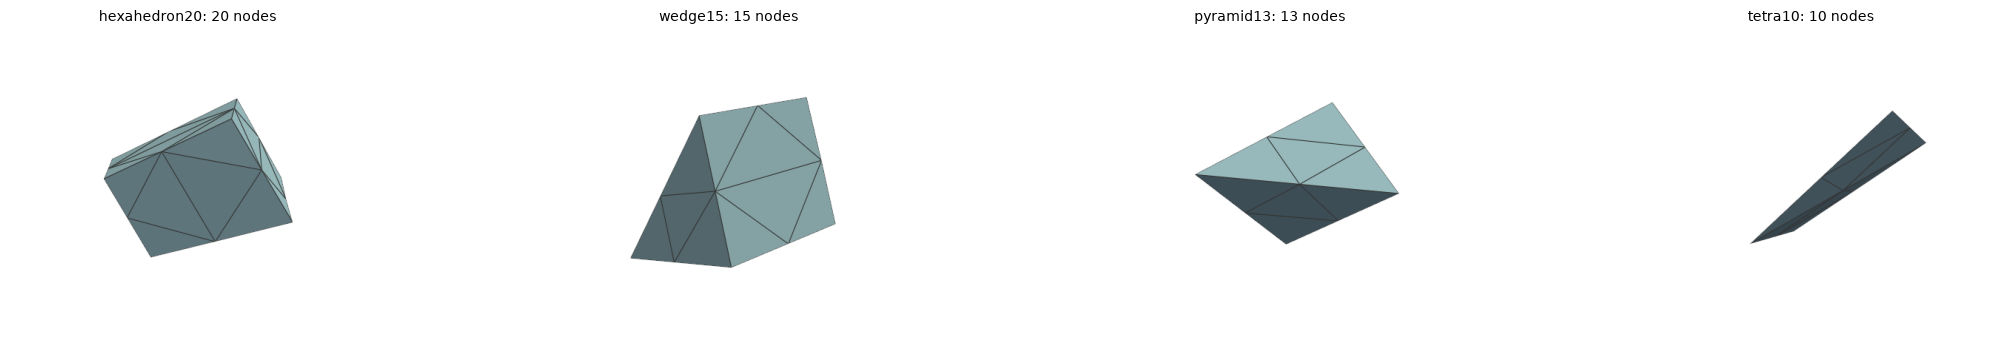

In [3]:
items = []
for block in solids.cells:
    row = block.data[0]
    one = mp.Mesh(solids.points[row], [(block.type, np.arange(len(row))[None])])
    items.append((to_grid(one), None, f'{block.type}: {len(row)} nodes', None))
gallery(items, ncols=4, size=(480, 420))

## Components as regions

`HexBeam.cdb` is a SOLID186 beam with two node components and two element components. They are point and cell regions, so they also show as `point_sets` and `cell_sets`. The element type, material, real constant and section number of every cell are `ansys:*` cell data.

NCOMP2          point   98 entries
NODE_SELECTION  point  164 entries
ECOMP1          cell    22 entries
ECOMP2          cell    22 entries
cell data: ['ansys:element', 'ansys:mat', 'ansys:real', 'ansys:secnum', 'ansys:type']
point sets: ['NCOMP2', 'NODE_SELECTION']


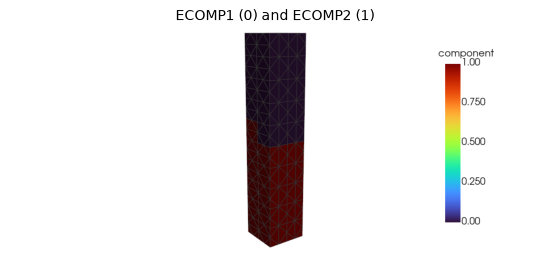

In [4]:
beam = mp.read(path('ansys', 'HexBeam.cdb'))
for r in beam.regions:
    print(f'{r.name:15s} {r.kind:5s} {len(r.entries):4d} entries')
print('cell data:', sorted(beam.cell_data))
print('point sets:', sorted(beam.point_sets))
gallery([
    (to_grid(beam, cell_data={'component': region_array(beam, ['ECOMP1', 'ECOMP2'])}), 'component', 'ECOMP1 (0) and ECOMP2 (1)', (0, 1)),
], ncols=1, size=(1000, 420))

## Missing midside nodes

MAPDL writes a midside node it dropped as node `0`, and some rows simply stop early. meshio++ creates each missing node at its edge midpoint, shared by the elements on that edge, with a warning that counts them. `mixed_missing_midside.cdb` mixes quadratic tetrahedra, pyramids, quads and triangles with such gaps.

In [5]:
source = path('ansys', 'mixed_missing_midside.cdb')
with open(source) as fh:
    in_file = next(int(line.split(',')[4]) for line in fh if line.startswith('NBLOCK'))  # its node count
mixed = mp.read(source)
print([(c.type, len(c.data)) for c in mixed.cells])
print(f'{in_file} nodes in the file, {len(mixed.points) - in_file} midside nodes created')

[('hexahedron', 21), ('tetra10', 236), ('pyramid13', 8), ('quad', 10), ('triangle6', 12)]
584 nodes in the file, 23 midside nodes created


## Writing a deck

A structured grid split into tetrahedra, plus a band of wedges, written as a `.cdb`. Tetrahedra go out as SOLID285, wedges as degenerate SOLID185 bricks (note the repeated nodes), and the regions as `CMBLOCK` components. The deck reads back to the same mesh.

In [6]:
tets = mp.convert_cells(mp.grid((4, 2, 2), spacing=(0.5, 0.5, 0.5)), mode='simplexify')
tets = mp.Mesh(tets.points, tets.cells)
base = len(tets.points)
wedge_points = np.array([[2.5, 0, 0], [3.0, 0, 0], [2.5, 1, 0], [2.5, 0, 1], [3.0, 0, 1], [2.5, 1, 1]])
mesh = mp.Mesh(np.vstack([tets.points, wedge_points]),
               [tets.cells[0], ('wedge', np.arange(base, base + 6)[None])])
mesh.regions = [mp.Region('TETS', 'cell', np.arange(len(tets.cells[0].data))),
                mp.Region('WEDGE_BASE', 'point', np.arange(base, base + 3))]
out = os.path.join(TMP, 'model.cdb')
mp.write(out, mesh)
with open(out) as fh:
    text = fh.read().splitlines()
print('\n'.join(l for l in text if l.startswith(('ET,', 'CMBLOCK'))))
eblock = text.index('(19i10)')
print('last element row:', text[eblock + len(tets.cells[0].data) + 1][100:])
back = mp.read(out)
print('same cells:', all(np.array_equal(a.data, b.data) for a, b in zip(back.cells, mesh.cells)),
      '| regions:', [(r.name, r.kind, len(r.entries)) for r in back.regions])

ET,1,285
ET,2,185
CMBLOCK,TETS,ELEM,       2
CMBLOCK,WEDGE_BASE,NODE,       2
last element row:         97        46        47        48        48        49        50        51        51
same cells: True | regions: [('WEDGE_BASE', 'point', 3), ('TETS', 'cell', 96)]


## Results: a modal analysis

`file.rst` is a modal analysis of a SOLID186 beam: six result sets, one per mode, whose "time" is the frequency. Each set's nodal solution `U` is point data. A node written in a rotated coordinate system would be rotated back to the global axes.

In [7]:
rst = path(os.path.join('ansys', 'rst'), 'file.rst')
freqs = mp.ansys_rst.time_values(rst)
print('frequencies (Hz):', np.round(freqs, 1))
mode = mp.read(rst)
print(mode)
print({k: v.tolist() for k, v in mode.field_data.items()})

frequencies (Hz): [ 7366.5  7366.5 11504.9 17285.7 17285.7 20137.2]
<meshio++ mesh object>
  Number of points: 321
  Number of cells:
    hexahedron20: 40
  Point data: U
  Cell data: ansys:element, ansys:mat, ansys:real, ansys:secnum, ansys:type
  Field data: ansys:cumulative, ansys:load_step, ansys:substep, meshio:time
{'ansys:cumulative': [1], 'ansys:load_step': [1], 'ansys:substep': [1], 'meshio:time': [7366.495039686105]}


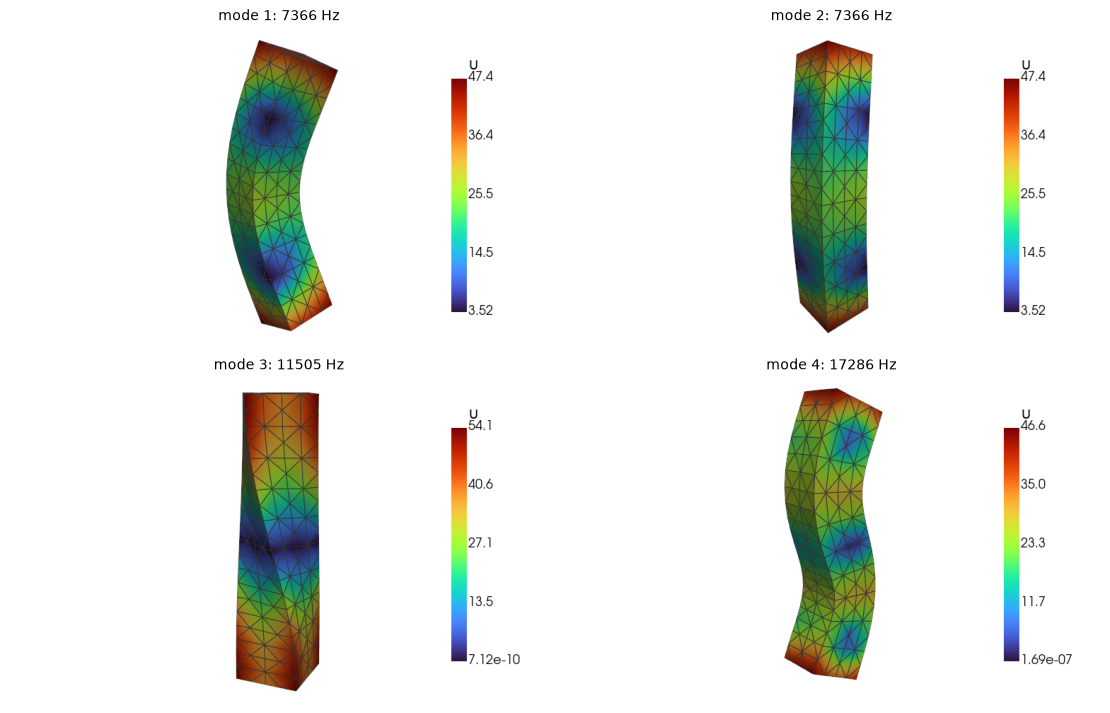

In [8]:
items = []
for k in range(4):
    m = mp.read(rst, time_step=k)
    u = m.point_data['U']
    scale = 0.3 / np.abs(u).max()
    warped = mp.Mesh(m.points + scale * u, m.cells)
    items.append((to_grid(warped, point_data={'|U|': np.linalg.norm(u, axis=1)}), '|U|',
                  f'mode {k + 1}: {freqs[k]:.0f} Hz', None))
gallery(items, ncols=2)

## Thermal results

`.rth` files hold the same layout with a `TEMP` degree of freedom, read as scalar point data.

<meshio++ mesh object>
  Number of points: 2720
  Number of cells:
    hexahedron20: 450
  Point sets: __NODE__
  Cell sets: __ELEM__
  Point data: TEMP
  Cell data: ansys:element, ansys:mat, ansys:real, ansys:secnum, ansys:type
  Field data: ansys:cumulative, ansys:load_step, ansys:substep, meshio:time
TEMP range: 4.99 .. 100.01


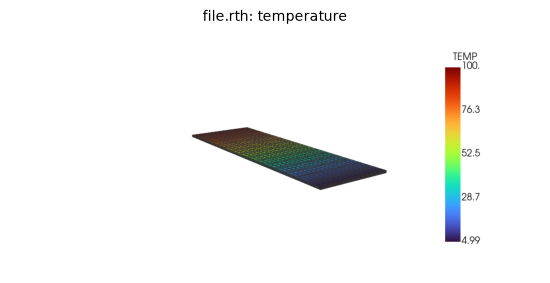

In [9]:
rth = mp.read(path(os.path.join('ansys', 'rst'), 'file.rth'))
print(rth)
t = rth.point_data['TEMP']
print('TEMP range:', round(float(t.min()), 2), '..', round(float(t.max()), 2))
gallery([(to_grid(rth, point_data={'TEMP': t}), 'TEMP', 'file.rth: temperature', None)], ncols=1, size=(1000, 460))

A whole analysis converts to one `.vtu` per result set, on the command line with `meshioplusplus convert file.rst 'mode_{step}.vtu'` or from Python:

In [10]:
mp.write_sequence(os.path.join(TMP, 'mode_{step}.vtu'), mp.read_sequence(rst))
print(sorted(f for f in os.listdir(TMP) if f.startswith('mode_')))

['mode_0000.vtu', 'mode_0001.vtu', 'mode_0002.vtu', 'mode_0003.vtu', 'mode_0004.vtu', 'mode_0005.vtu']


## What was checked

- **`.cdb`:** every deck in mapdl-archive's repository reads in both engines to the cells mapdl-archive builds (compared as sets of node coordinates) and the same components. The one difference is three missing triangle midsides that mapdl-archive puts at the origin. MAPDL was not available, so written decks are checked by reading them back.
- **`.rst`:** every non-distributed result file in pymapdl-reader's repository reads to the cells, set times and nodal solutions pymapdl-reader gives, bit for bit, except where pymapdl-reader reads past a record (sets holding only some nodes). A synthetic file in the tests pins a node rotated about three axes, a partial set and MAPDL's undefined value.
- Element results (stresses, strains) are not read yet: see the roadmap.

See the [coded database](../../doc/formats/ansysinp.md) and [results](../../doc/formats/ansys_rst.md) pages.